In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [2]:
def fetch_data(ticker, start="2018-01-01", end="2026-01-01"):
    df = yf.download(ticker, start=start, end=end)
    print(f"Downloaded {len(df)} days of {ticker} data")
    print(df.head())
    return df


df = fetch_data("AAPL")


[*********************100%***********************]  1 of 1 completed

Downloaded 2011 days of AAPL data
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.267075  40.276427  39.565802  39.776186  102223600
2018-01-03  40.260059  40.802379  40.196947  40.330187  118071600
2018-01-04  40.447067  40.549921  40.224998  40.332525   89738400
2018-01-05  40.907581  40.994071  40.451755  40.542920   94640000
2018-01-08  40.755627  41.050160  40.657445  40.755627   82271200


In [3]:


def prepare_data(df):
    
    data = df[['Close']].copy()
    
    # Split 80/20 by time
    train_size = int(len(data) * 0.8)
    train = data[:train_size]
    test = data[train_size:]
    
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)
    
    def create_sequences(data, seq_length=30):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            y.append(data[i+seq_length])
        return np.array(X), np.array(y)
    
    X_train, y_train = create_sequences(train_scaled)
    X_test, y_test = create_sequences(test_scaled)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)
    
    return X_train_t, y_train_t, X_test_t, y_test_t, scaler

In [4]:
import torch
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")



class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = StockLSTM(input_size=1, hidden_size=64, num_layers=2).to(device)
print(model)

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [5]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
def train_model(model, X_train, y_train, epochs=100):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train).squeeze()
        loss = loss_fn(y_pred, y_train.squeeze())
        loss.backward()
        optimizer.step()
        
        if (epoch+1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")
    
    return model

In [7]:
def predict_and_plot(model, X_test, y_test, scaler, ticker):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).cpu().numpy()
        y_pred_rescaled = scaler.inverse_transform(y_pred)
        y_test_rescaled = scaler.inverse_transform(y_test.cpu().numpy())
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_rescaled, label='Actual')
    plt.plot(y_pred_rescaled, label='Predicted')
    plt.title(f"{ticker} Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


[*********************100%***********************]  1 of 1 completed


Downloaded 2011 days of AMZN data
Price           Close       High        Low       Open    Volume
Ticker           AMZN       AMZN       AMZN       AMZN      AMZN
Date                                                            
2018-01-02  59.450500  59.500000  58.525501  58.599998  53890000
2018-01-03  60.209999  60.274502  59.415001  59.415001  62176000
2018-01-04  60.479500  60.793499  60.233002  60.250000  60442000
2018-01-05  61.457001  61.457001  60.500000  60.875500  70894000
2018-01-08  62.343498  62.653999  61.601501  61.799999  85590000
Epoch [20/100], Loss: 0.075866
Epoch [40/100], Loss: 0.036754
Epoch [60/100], Loss: 0.007323
Epoch [80/100], Loss: 0.003650
Epoch [100/100], Loss: 0.002742


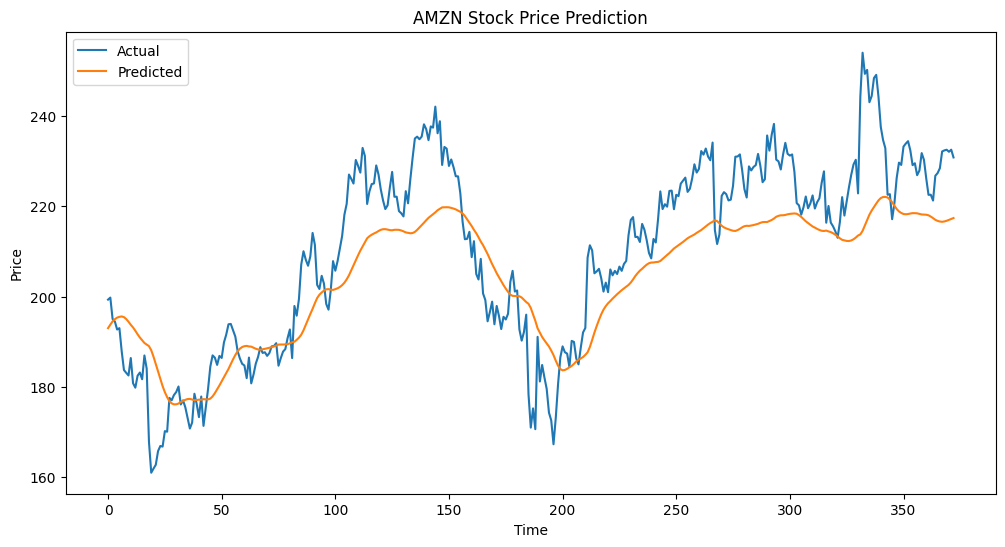

In [8]:

TICKER = "AMZN"  # ⭐ CHANGE THIS TO ANY STOCK TICKER

# Run full pipeline
df = fetch_data(TICKER)
X_train, y_train, X_test, y_test, scaler = prepare_data(df)
model = StockLSTM(input_size=1, hidden_size=64, num_layers=2).to(device)
model = train_model(model, X_train, y_train, epochs=100)
predict_and_plot(model, X_test, y_test, scaler, TICKER)

In [9]:
def prediction_future(model, last_sequence, scaler, future_days=30):
    model.eval()
    predictions = []
    current_seq = last_sequence
    
    with torch.no_grad():
        for _ in range(future_days):
            pred = model(current_seq.unsqueeze(0)).squeeze().cpu().numpy()
            predictions.append(pred)
            current_seq = torch.cat((current_seq[1:], torch.tensor(pred).reshape(1, 1).to(device)))


    
    predictions_rescaled = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return predictions_rescaled

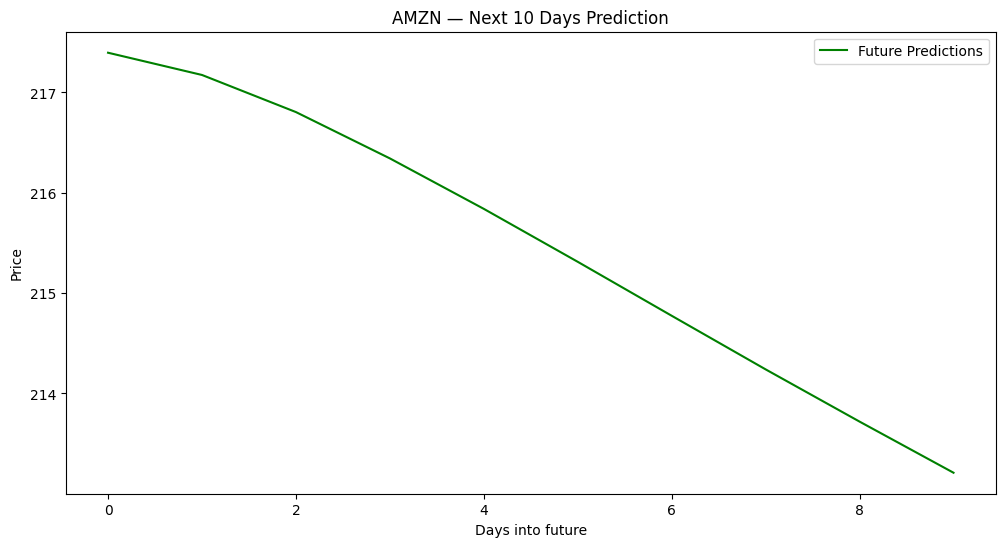

In [10]:
# Get last 30 days from training data
last_seq = X_test[-1]  # last sequence in test set

future_prices = prediction_future(model, last_seq, scaler, future_days=10)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(future_prices, label='Future Predictions', color='green')
plt.title(f"{TICKER} — Next 10 Days Prediction")
plt.xlabel("Days into future")
plt.ylabel("Price")
plt.legend()
plt.show()

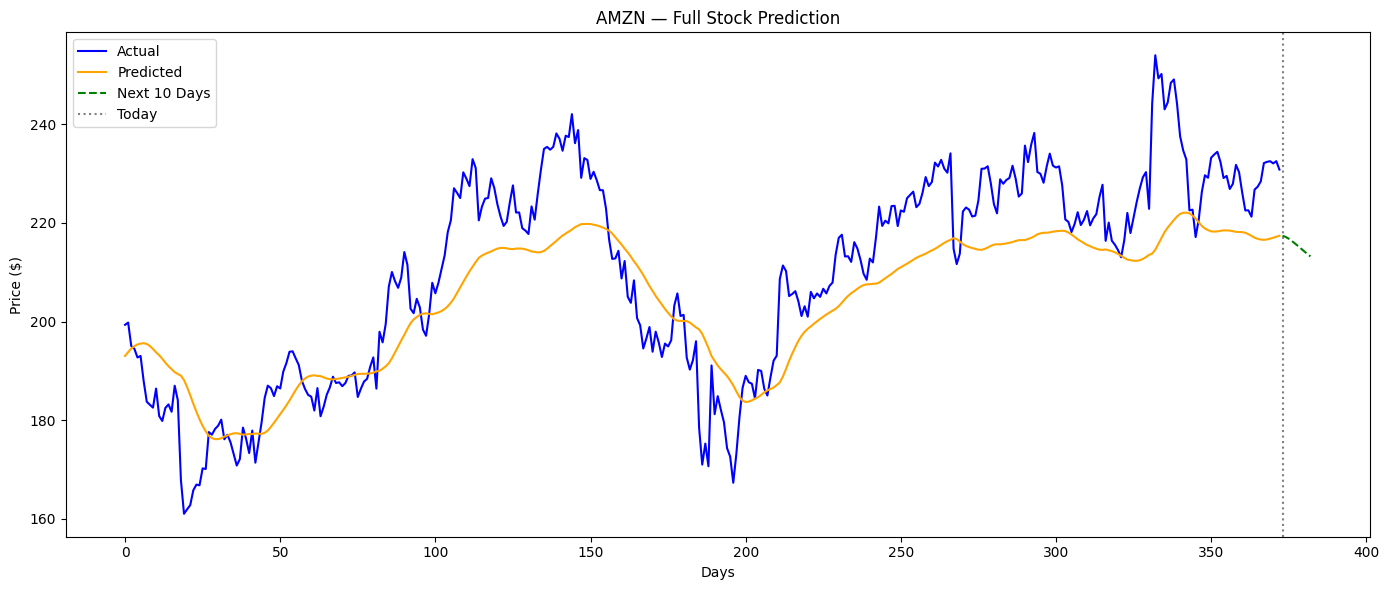

In [11]:

def predict_and_plot(model, X_test, y_test, scaler, ticker):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).cpu().numpy()
        y_pred_rescaled = scaler.inverse_transform(y_pred)
        y_test_rescaled = scaler.inverse_transform(y_test.cpu().numpy())
    
    return y_test_rescaled, y_pred_rescaled


actual_rescaled, predicted_rescaled = predict_and_plot(model, X_test, y_test, scaler, TICKER)

# Get future predictions
last_seq = X_test[-1]
future_prices = prediction_future(model, last_seq, scaler, future_days=10)


plt.figure(figsize=(14, 6))
plt.plot(actual_rescaled, label='Actual', color='blue')
plt.plot(predicted_rescaled, label='Predicted', color='orange')

future_start = len(actual_rescaled)
future_x = range(future_start, future_start + 10)
plt.plot(future_x, future_prices, label='Next 10 Days', color='green', linestyle='--')
plt.axvline(x=future_start, color='gray', linestyle=':', label='Today')

plt.title(f"{TICKER} — Full Stock Prediction")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
torch.save(model.state_dict(), 'stock_model.pth')